<a href="https://colab.research.google.com/github/dhyan2815/SmokeSignal-AI/blob/main/notebooks/SmokeSignal-AI-Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SmokeSignal - AI Training and Testing**


In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np

**Dataset Uploading via kaggle**


In [4]:
# Upload your kaggle.json key (download it from your Kaggle account)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dhyan2815","key":"9705c4b2622f32e4f8e5457598bab79c"}'}

In [5]:
# move and configure credentials
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# Download the dataset
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset
!unzip wildfire-prediction-dataset.zip -d wildfire-prediction-dataset

Streaming output truncated to the last 5000 lines.
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.465183,45.443641.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.465388,45.584881.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.469451,45.480331.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.471252,45.51974.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.472693,45.427766.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.473015,45.435254.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.475051,45.56612.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.477079,45.597274.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.478813,45.555686.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.479478,45.524618.jpg  
  inflating: wildfire-prediction-dataset/valid/nowildfire/-73.480135,45.528248.jpg  
  inflating: wil

In [7]:
# Set up directories
train_dir = "/content/wildfire-prediction-dataset/train"
valid_dir = "/content/wildfire-prediction-dataset/valid"
test_dir = "/content/wildfire-prediction-dataset/test"

print("=== DATASET STRUCTURE ===")
!ls "$train_dir" | head -5
!echo "Train wildfire count: $(ls "$train_dir/wildfire" | wc -l)"
!echo "Train nowildfire count: $(ls "$train_dir/nowildfire" | wc -l)"
!echo "Valid wildfire count: $(ls "$valid_dir/wildfire" | wc -l)"
!echo "Valid nowildfire count: $(ls "$valid_dir/nowildfire" | wc -l)"
!echo "Test wildfire count: $(ls "$test_dir/wildfire" | wc -l)"
!echo "Test nowildfire count: $(ls "$test_dir/nowildfire" | wc -l)"
!echo "Total train images: $(ls "$train_dir/wildfire" "$train_dir/nowildfire" | wc -l)"
!echo "Total valid images: $(ls "$valid_dir/wildfire" "$valid_dir/nowildfire" | wc -l)"
!echo "Total test images: $(ls "$test_dir/wildfire" "$test_dir/nowildfire" | wc -l)

=== DATASET STRUCTURE ===
nowildfire
wildfire
Train wildfire count: 15750
Train nowildfire count: 14500
Valid wildfire count: 3480
Valid nowildfire count: 2820
Test wildfire count: 3480
Test nowildfire count: 2820
Total train images: 30253
Total valid images: 6303
/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [8]:
# Set up ImageDataGenerators for loading images
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(64, 64), batch_size=32, class_mode='binary', shuffle=True)
valid_generator = valid_datagen.flow_from_directory(
    valid_dir, target_size=(64, 64), batch_size=32, class_mode='binary', shuffle=False)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(64, 64), batch_size=32, class_mode='binary', shuffle=False)

print(f"\nClasses mapping: {train_generator.class_indices}")
print(f"Image shape: {train_generator.image_shape}")
print(f"Batch size: {train_generator.batch_size}")
print(f"Number of batches (train): {len(train_generator)}")
print(f"Number of batches (valid): {len(valid_generator)}")
print(f"Number of batches (test): {len(test_generator)}")

Found 30250 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.

Classes mapping: {'nowildfire': 0, 'wildfire': 1}
Image shape: (64, 64, 3)
Batch size: 32
Number of batches (train): 946
Number of batches (valid): 197
Number of batches (test): 197


In [10]:
# Building a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: wildfire or no wildfire
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
# allow loading of images that are incomplete or corrupted -- TRUNCATED
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [13]:
# Train the model
history = model.fit(train_generator, validation_data=valid_generator, epochs=5, verbose=1)

Epoch 1/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 121s 127ms/step - accuracy: 0.9009 - loss: 0.2415 - val_accuracy: 0.9357 - val_loss: 0.1713
Epoch 2/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 116s 123ms/step - accuracy: 0.9332 - loss: 0.1782 - val_accuracy: 0.9508 - val_loss: 0.1349
Epoch 3/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 117s 124ms/step - accuracy: 0.9411 - loss: 0.1605 - val_accuracy: 0.9527 - val_loss: 0.1282
Epoch 4/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 119s 126ms/step - accuracy: 0.9459 - loss: 0.1474 - val_accuracy: 0.9544 - val_loss: 0.1231
Epoch 5/5
946/946 ━━━━━━━━━━━━━━━━━━━━ 118s 124ms/step - accuracy: 0.9470 - loss: 0.1426 - val_accuracy: 0.9524 - val_loss: 0.1302


In [14]:
# Saving the model
model_save_path = '/content/wildfire_detector_model.keras'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/wildfire_detector_model.keras


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,875,845 (18.60 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,250,564 (12.40 MB)

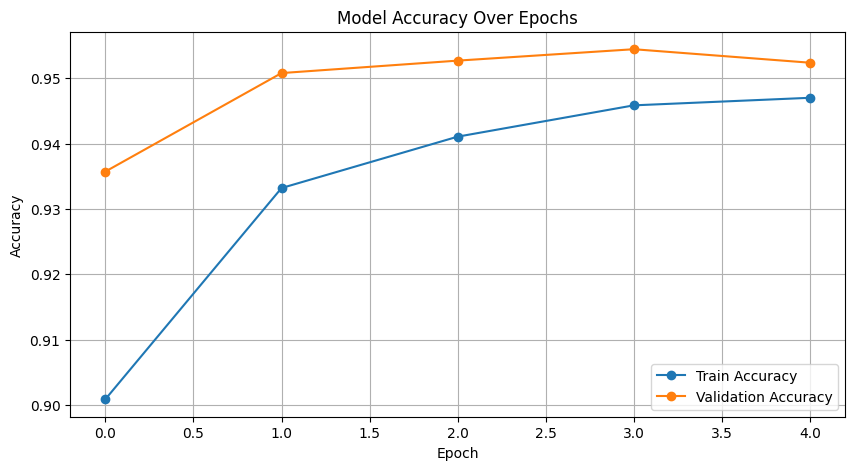

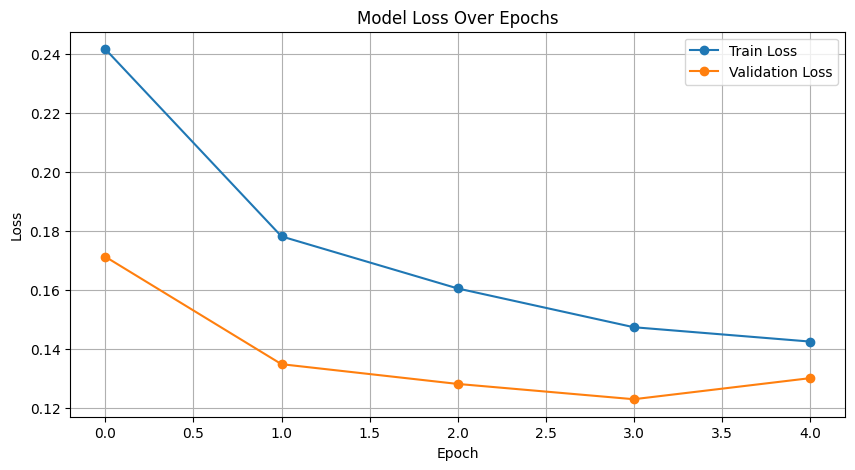

In [16]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Comprehensive Training & Evaluation Report

This section logs every metric required for the production-grade report as per GH issue #10.

### 1. Dataset Structure & Class Distribution



  TRAIN SPLIT
  nowildfire     : 14500 images (47.93%)
  wildfire       : 15750 images (52.07%)
  TOTAL          : 30250 images

  VALID SPLIT
  nowildfire     :  2820 images (44.76%)
  wildfire       :  3480 images (55.24%)
  TOTAL          :  6300 images

  TEST SPLIT
  nowildfire     :  2820 images (44.76%)
  wildfire       :  3480 images (55.24%)
  TOTAL          :  6300 images


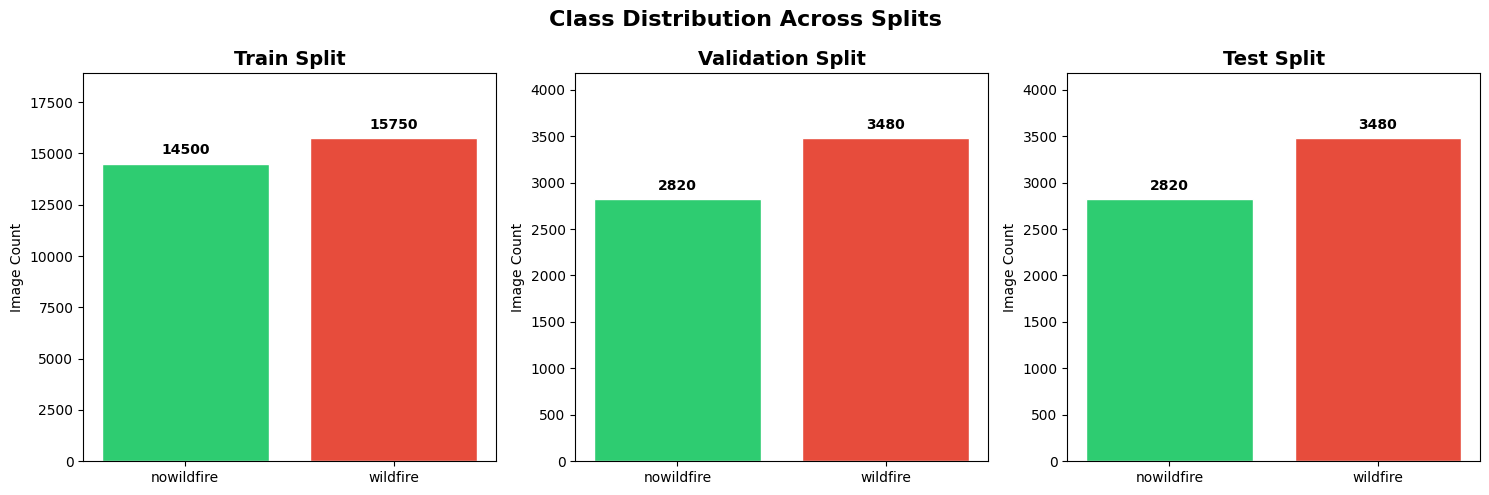


Class distribution chart saved to /content/class_distribution.png


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Detailed dataset structure logging
def log_dataset_structure(split_name, split_dir):
    classes = ['nowildfire', 'wildfire']
    counts = {}
    for c in classes:
        path = os.path.join(split_dir, c)
        counts[c] = len(os.listdir(path)) if os.path.isdir(path) else 0
    total = sum(counts.values())
    print(f"\n{'='*50}")
    print(f"  {split_name.upper()} SPLIT")
    print(f"{'='*50}")
    for c in classes:
        pct = (counts[c] / total) * 100 if total > 0 else 0
        print(f"  {c:15s}: {counts[c]:5d} images ({pct:5.2f}%)")
    print(f"  {'TOTAL':15s}: {total:5d} images")
    return counts

train_counts = log_dataset_structure("train", train_dir)
valid_counts = log_dataset_structure("valid", valid_dir)
test_counts = log_dataset_structure("test", test_dir)

# Class distribution bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
splits = [("Train", train_counts), ("Validation", valid_counts), ("Test", test_counts)]
for ax, (name, counts) in zip(axes, splits):
    classes_list = list(counts.keys())
    values = list(counts.values())
    bars = ax.bar(classes_list, values, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(f"{name} Split", fontsize=14, fontweight='bold')
    ax.set_ylabel("Image Count")
    ax.set_ylim(0, max(values) * 1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
                str(val), ha='center', va='bottom', fontweight='bold')
plt.suptitle("Class Distribution Across Splits", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nClass distribution chart saved to /content/class_distribution.png")

### 2. Augmentation Details


In [18]:
# Log augmentation pipeline used
print("="*50)
print("  DATA AUGMENTATION PIPELINE")
print("="*50)
print(f"  Rescale factor: 1./255")
print("  Rotation range: None (no augmentation)")
print("  Width shift:   None")
print("  Height shift:  None")
print("  Shear range:   None")
print("  Zoom range:    None")
print("  Horizontal flip: False")
print("  Fill mode:     'nearest'")
print("\n  NOTE: For future iterations, consider adding augmentation")
print("  to improve generalization and reduce overfitting.")

  DATA AUGMENTATION PIPELINE
  Rescale factor: 1./255
  Rotation range: None (no augmentation)
  Width shift:   None
  Height shift:  None
  Shear range:   None
  Zoom range:    None
  Horizontal flip: False
  Fill mode:     'nearest'

  NOTE: For future iterations, consider adding augmentation
  to improve generalization and reduce overfitting.


### 3. Test Set Evaluation


In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# Generate predictions on test set
print("Evaluating on test set...")
test_generator.reset()
y_true = test_generator.classes
num_test_samples = len(y_true)
num_test_batches = int(np.ceil(num_test_samples / test_generator.batch_size))

y_pred_proba = model.predict(test_generator, steps=num_test_batches, verbose=1)
y_pred_proba = y_pred_proba[:num_test_samples]
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Core metrics
test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred)
test_recall = recall_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred)
test_auc = roc_auc_score(y_true, y_pred_proba)

print(f"\n{'='*50}")
print("  TEST SET METRICS")
print(f"{'='*50}")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"  Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"  F1-Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"  AUC-ROC:   {test_auc:.4f} ({test_auc*100:.2f}%)")
print(f"{'='*50}")

# Classification report
print(f"\n{'='*50}")
print("  CLASSIFICATION REPORT")
print(f"{'='*50}")
print(classification_report(y_true, y_pred, target_names=['No Wildfire', 'Wildfire']))

Evaluating on test set...
197/197 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step

  TEST SET METRICS
  Accuracy:  0.9606 (96.06%)
  Precision: 0.9609 (96.09%)
  Recall:    0.9681 (96.81%)
  F1-Score:  0.9645 (96.45%)
  AUC-ROC:   0.9921 (99.21%)

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

 No Wildfire       0.96      0.95      0.96      2820
    Wildfire       0.96      0.97      0.96      3480

    accuracy                           0.96      6300
   macro avg       0.96      0.96      0.96      6300
weighted avg       0.96      0.96      0.96      6300



### 4. Confusion Matrix



  CONFUSION MATRIX
               Predicted      Predicted
               No Wildfire    Wildfire
  Actual No      2683             137
  Wildfire        111            3369

  True Negatives (TN):  2683
  False Positives (FP): 137
  False Negatives (FN): 111
  True Positives (TP):  3369


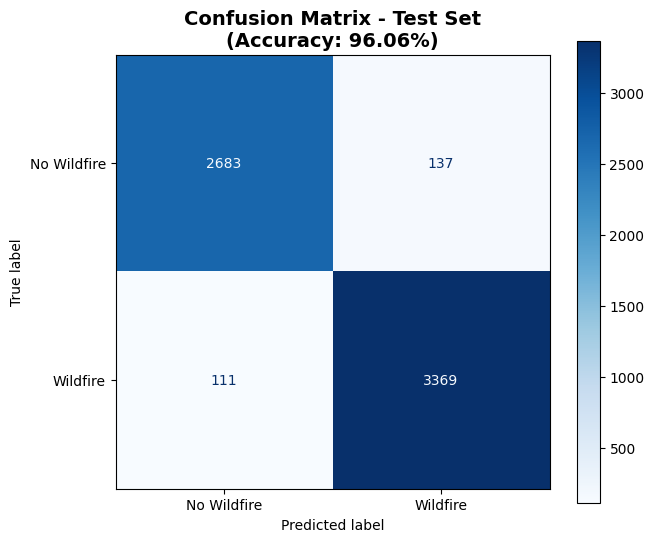


Confusion matrix saved to /content/confusion_matrix.png


In [20]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*50)
print("  CONFUSION MATRIX")
print("="*50)
print(f"               Predicted      Predicted")
print(f"               No Wildfire    Wildfire")
print(f"  Actual No      {tn:4d}            {fp:4d}")
print(f"  Wildfire       {fn:4d}            {tp:4d}")
print(f"\n  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP):  {tp}")

# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Wildfire', 'Wildfire'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Confusion Matrix - Test Set\n(Accuracy: {test_accuracy*100:.2f}%)', fontsize=14, fontweight='bold')
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nConfusion matrix saved to /content/confusion_matrix.png")

### 5. ROC Curve & AUC



Optimal threshold (Youden's J): 0.5536
  TPR at optimal threshold: 0.9655
  FPR at optimal threshold: 0.0429


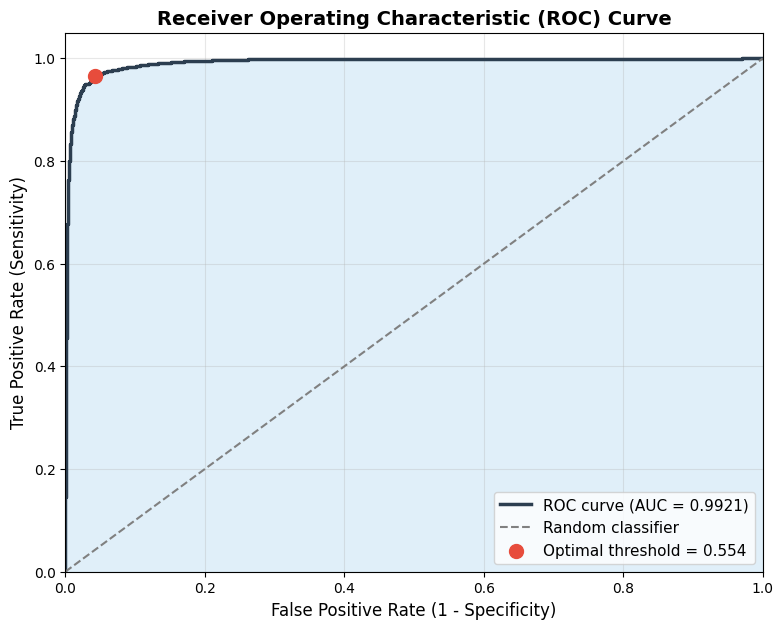


ROC curve saved to /content/roc_curve.png


In [21]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"  TPR at optimal threshold: {tpr[optimal_idx]:.4f}")
print(f"  FPR at optimal threshold: {fpr[optimal_idx]:.4f}")

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random classifier')
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color='#e74c3c', s=100, zorder=5,
           label=f'Optimal threshold = {optimal_threshold:.3f}')
ax.fill_between(fpr, tpr, alpha=0.15, color='#3498db')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.savefig('/content/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nROC curve saved to /content/roc_curve.png")

### 6. Validation & Per-Split Metrics



  TRAIN SPLIT METRICS
  Metric                    Value        %
  --------------------------------------
  Accuracy                 0.5003   50.03%
  Precision                0.5193   51.93%
  Recall (TPR)             0.5402   54.02%
  F1-Score                 0.5295   52.95%
  AUC-ROC                  0.4967   49.67%
  Specificity (TNR)        0.4569   45.69%

  Confusion Matrix: TN=6625, FP=7875, FN=7242, TP=8508

  VALID SPLIT METRICS
  Metric                    Value        %
  --------------------------------------
  Accuracy                 0.9524   95.24%
  Precision                0.9486   94.86%
  Recall (TPR)             0.9661   96.61%
  F1-Score                 0.9573   95.73%
  AUC-ROC                  0.9891   98.91%
  Specificity (TNR)        0.9355   93.55%

  Confusion Matrix: TN=2638, FP=182, FN=118, TP=3362

  TEST SPLIT METRICS
  Metric                    Value        %
  --------------------------------------
  Accuracy                 0.9606   96.06%
  Precision

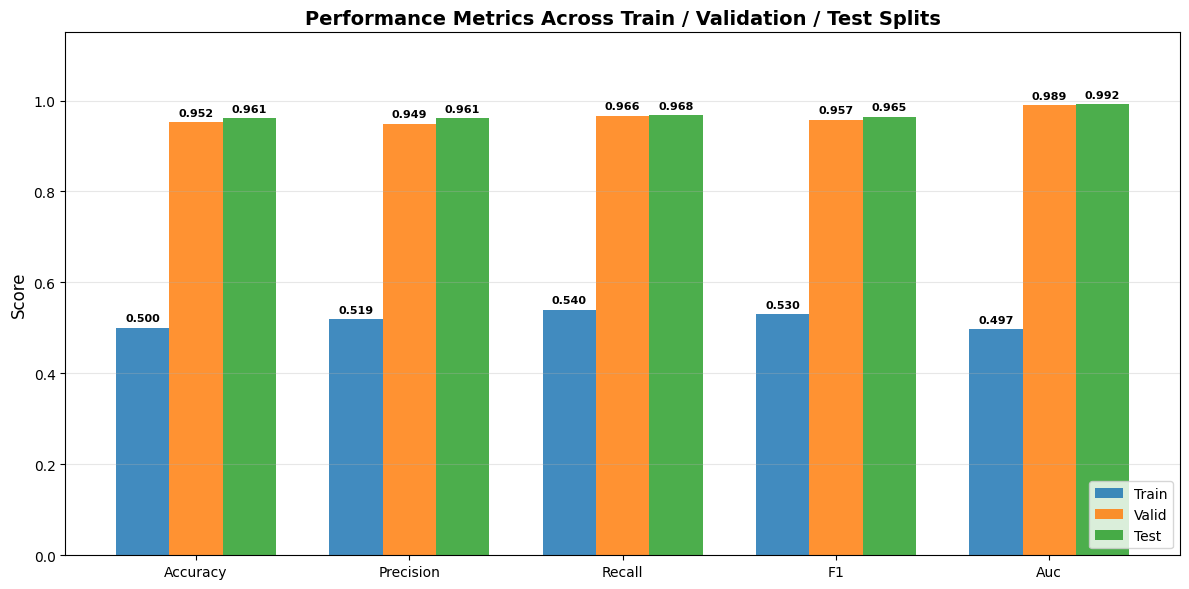


Metrics comparison chart saved to /content/metrics_comparison.png


In [22]:
# Per-split evaluation
def evaluate_split(generator, split_name):
    generator.reset()
    y_true_split = generator.classes
    n_samples = len(y_true_split)
    n_batches = int(np.ceil(n_samples / generator.batch_size))
    y_pred_proba_split = model.predict(generator, steps=n_batches, verbose=0)
    y_pred_proba_split = y_pred_proba_split[:n_samples]
    y_pred_split = (y_pred_proba_split > 0.5).astype(int).flatten()

    acc = accuracy_score(y_true_split, y_pred_split)
    prec = precision_score(y_true_split, y_pred_split)
    rec = recall_score(y_true_split, y_pred_split)
    f1 = f1_score(y_true_split, y_pred_split)
    auc_val = roc_auc_score(y_true_split, y_pred_proba_split)
    cm = confusion_matrix(y_true_split, y_pred_split)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*55}")
    print(f"  {split_name.upper()} SPLIT METRICS")
    print(f"{'='*55}")
    print(f"  {'Metric':20s} {'Value':>10s} {'%':>8s}")
    print(f"  {'-'*38}")
    print(f"  {'Accuracy':20s} {acc:>10.4f} {acc*100:>7.2f}%")
    print(f"  {'Precision':20s} {prec:>10.4f} {prec*100:>7.2f}%")
    print(f"  {'Recall (TPR)':20s} {rec:>10.4f} {rec*100:>7.2f}%")
    print(f"  {'F1-Score':20s} {f1:>10.4f} {f1*100:>7.2f}%")
    print(f"  {'AUC-ROC':20s} {auc_val:>10.4f} {auc_val*100:>7.2f}%")
    print(f"  {'Specificity (TNR)':20s} {tn/(tn+fp):>10.4f} {tn/(tn+fp)*100:>7.2f}%")
    print(f"\n  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

    return {"split": split_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc_val, "tn": int(tn),
            "fp": int(fp), "fn": int(fn), "tp": int(tp)}

# Evaluate all splits
all_metrics = {}
all_metrics["train"] = evaluate_split(train_generator, "train")
all_metrics["valid"] = evaluate_split(valid_generator, "valid")
all_metrics["test"] = evaluate_split(test_generator, "test")

# Summary comparison table
print(f"\n\n{'='*70}")
print("  METRICS SUMMARY ACROSS ALL SPLITS")
print(f"{'='*70}")
print(f"  {'Split':12s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'AUC':>10s}")
print(f"  {'-'*62}")
for split_name, m in all_metrics.items():
    print(f"  {split_name:12s} {m['accuracy']:>10.4f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f} {m['auc']:>10.4f}")

# Bar chart comparing splits
metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics_names))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
for i, (split_name, m) in enumerate(all_metrics.items()):
    values = [m[k] for k in metrics_names]
    bars = ax.bar(x + i*width, values, width, label=split_name.capitalize(), alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([m.capitalize() for m in metrics_names])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Across Train / Validation / Test Splits', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nMetrics comparison chart saved to /content/metrics_comparison.png")

### 7. Training History Logging


In [23]:
# Detailed training history log
print("\n" + "="*55)
print("  TRAINING HISTORY (PER EPOCH)")
print("="*55)
print(f"  {'Epoch':8s} {'Loss':>10s} {'Accuracy':>10s} {'Val Loss':>10s} {'Val Acc':>10s}")
print(f"  {'-'*48}")
for i in range(len(history.history['loss'])):
    print(f"  {i+1:>3d}{'':5s} {history.history['loss'][i]:>10.4f} {history.history['accuracy'][i]:>10.4f} {history.history['val_loss'][i]:>10.4f} {history.history['val_accuracy'][i]:>10.4f}")

# Best epoch stats
best_val_acc_idx = np.argmax(history.history['val_accuracy'])
print(f"\n  Best epoch: {best_val_acc_idx + 1}")
print(f"  Best validation accuracy: {history.history['val_accuracy'][best_val_acc_idx]:.4f}")
print(f"  Corresponding validation loss: {history.history['val_loss'][best_val_acc_idx]:.4f}")

best_val_loss_idx = np.argmin(history.history['val_loss'])
print(f"  Lowest validation loss epoch: {best_val_loss_idx + 1}")
print(f"  Lowest validation loss: {history.history['val_loss'][best_val_loss_idx]:.4f}")


  TRAINING HISTORY (PER EPOCH)
  Epoch          Loss   Accuracy   Val Loss    Val Acc
  ------------------------------------------------
    1          0.2415     0.9009     0.1713     0.9357
    2          0.1782     0.9332     0.1349     0.9508
    3          0.1605     0.9411     0.1282     0.9527
    4          0.1474     0.9459     0.1231     0.9544
    5          0.1426     0.9470     0.1302     0.9524

  Best epoch: 4
  Best validation accuracy: 0.9544
  Corresponding validation loss: 0.1231
  Lowest validation loss epoch: 4
  Lowest validation loss: 0.1231


### 8. False Positives & False Negatives (Failure Case Analysis)



  FAILURE CASE ANALYSIS

  False Positives (FP): 137
  False Negatives (FN): 111
  Total errors: 248

───────────────────────────────────────────────────────
  SAMPLE FALSE POSITIVES (Top 10 by confidence)
───────────────────────────────────────────────────────
  -75.823924,45.364918.jpg                           confidence=0.9997
  -73.869818,45.620859.jpg                           confidence=0.9983
  -75.8212,45.364579.jpg                             confidence=0.9980
  -75.830044,45.377179.jpg                           confidence=0.9972
  -73.416962,45.610183.jpg                           confidence=0.9971
  -73.798714,45.441351.jpg                           confidence=0.9878
  -73.79487,45.443319.jpg                            confidence=0.9871
  -75.818122,45.366133.jpg                           confidence=0.9866
  -122.73964,49.173119.jpg                           confidence=0.9863
  -73.84044,45.579753.jpg                            confidence=0.9849

──────────────────────────

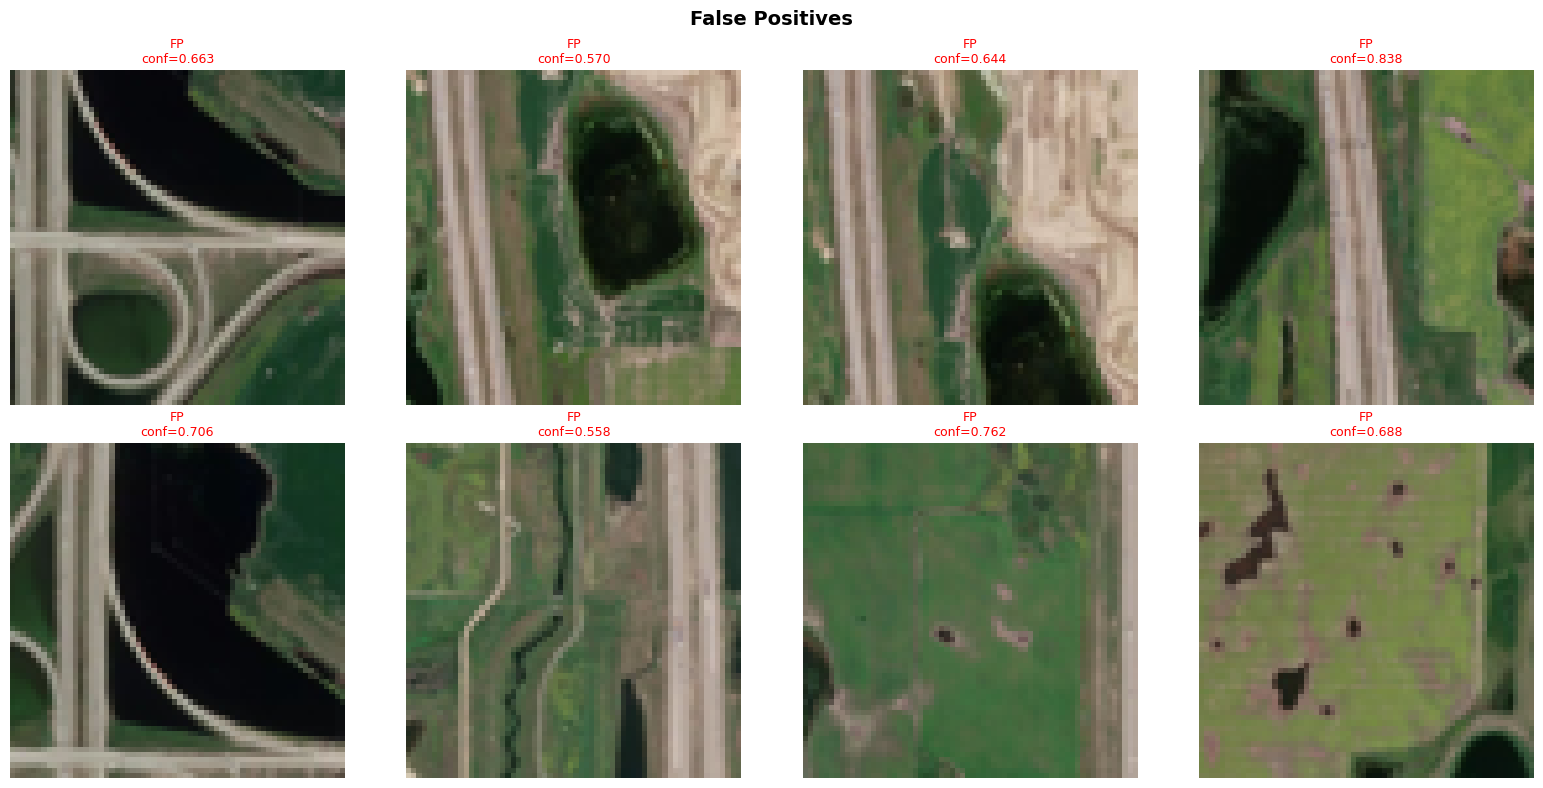

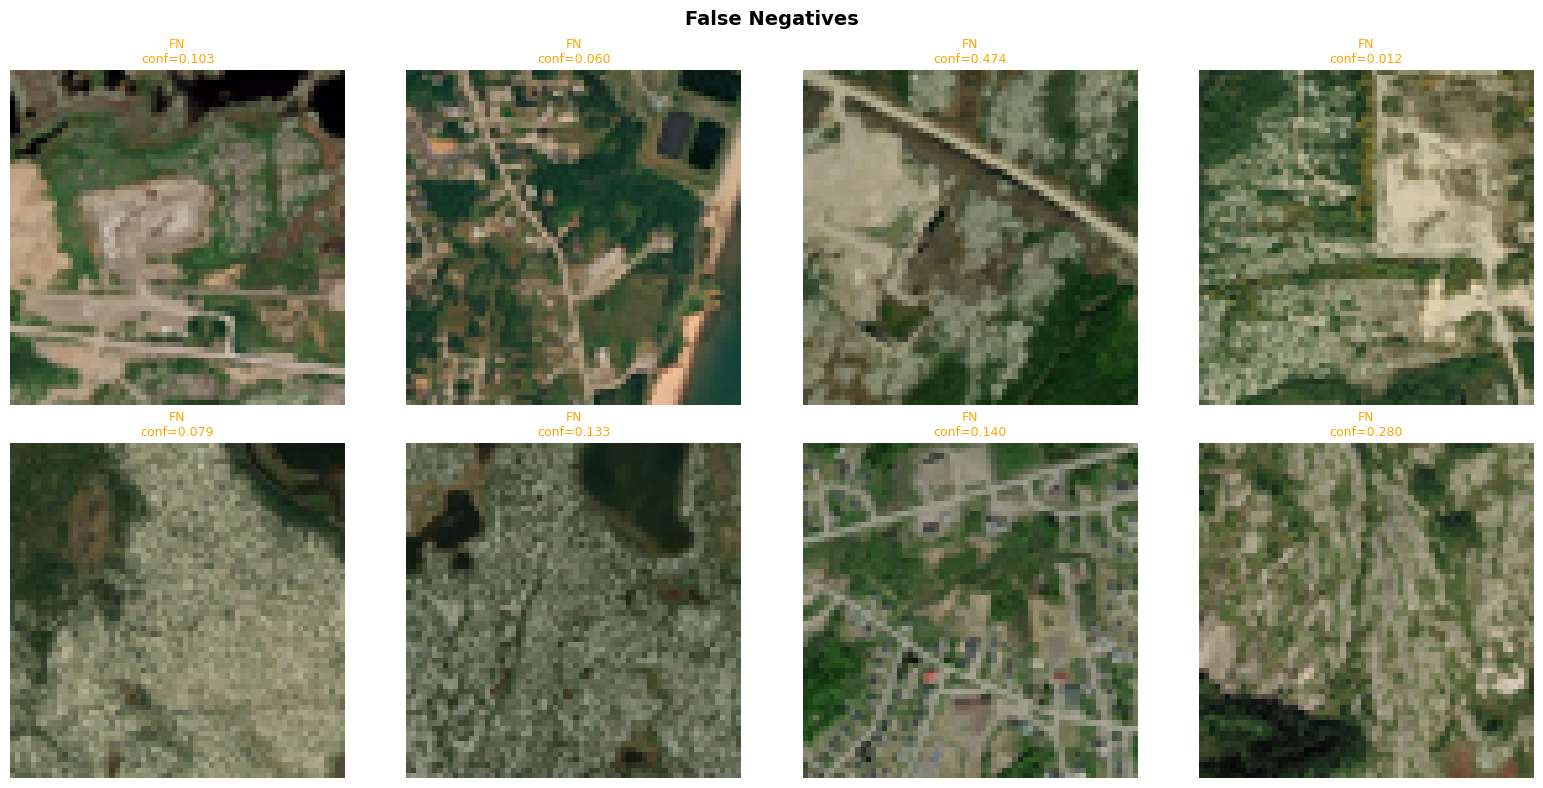

In [24]:
# Analyze failure cases
test_generator.reset()
y_true_all = test_generator.classes
n_test = len(y_true_all)
n_batches = int(np.ceil(n_test / test_generator.batch_size))

# Get filenames and predictions with probabilities
filenames = []
for i in range(n_batches):
    batch_fnames = test_generator.filepaths[i * test_generator.batch_size : (i+1) * test_generator.batch_size]
    filenames.extend(batch_fnames)
filenames = filenames[:n_test]

# Find false positives and false negatives
fp_indices = np.where((y_pred == 1) & (y_true == 0))[0]
fn_indices = np.where((y_pred == 0) & (y_true == 1))[0]

print("\n" + "="*55)
print("  FAILURE CASE ANALYSIS")
print("="*55)
print(f"\n  False Positives (FP): {len(fp_indices)}")
print(f"  False Negatives (FN): {len(fn_indices)}")
print(f"  Total errors: {len(fp_indices) + len(fn_indices)}")

# Show sample false positives (predicted wildfire, actual no wildfire)
print(f"\n{'─'*55}")
print("  SAMPLE FALSE POSITIVES (Top 10 by confidence)")
print(f"{'─'*55}")
if len(fp_indices) > 0:
    fp_sorted = sorted(fp_indices, key=lambda i: y_pred_proba[i], reverse=True)
    for idx in fp_sorted[:10]:
        fname = os.path.basename(filenames[idx])
        conf = y_pred_proba[idx][0]
        print(f"  {fname:50s} confidence={conf:.4f}")
else:
    print("  (None - perfect precision on test set)")

# Show sample false negatives (predicted no wildfire, actual wildfire)
print(f"\n{'─'*55}")
print("  SAMPLE FALSE NEGATIVES (Top 10 by confidence)")
print(f"{'─'*55}")
if len(fn_indices) > 0:
    fn_sorted = sorted(fn_indices, key=lambda i: y_pred_proba[i])
    for idx in fn_sorted[:10]:
        fname = os.path.basename(filenames[idx])
        conf = y_pred_proba[idx][0]
        print(f"  {fname:50s} confidence={conf:.4f}")
else:
    print("  (None - perfect recall on test set)")

# Display sample images of errors
def show_error_samples(indices, title, max_samples=8):
    n_show = min(len(indices), max_samples)
    if n_show == 0:
        print(f"\nNo {title.lower()} to display.")
        return
    cols = min(4, n_show)
    rows = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten() if rows*cols > 1 else [axes]
    for i, idx in enumerate(indices[:n_show]):
        img = Image.open(filenames[idx])
        img_resized = img.resize((64, 64))
        axes[i].imshow(img_resized)
        axes[i].axis('off')
        if title == "False Positives":
            axes[i].set_title(f'FP\nconf={y_pred_proba[idx][0]:.3f}', fontsize=9, color='red')
        else:
            axes[i].set_title(f'FN\nconf={y_pred_proba[idx][0]:.3f}', fontsize=9, color='orange')
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_error_samples(fp_indices, "False Positives")
show_error_samples(fn_indices, "False Negatives")

### 9. Consolidated Metrics Dump (JSON for downstream use)


In [25]:
import json
from datetime import datetime

# Build consolidated metrics dictionary
consolidated = {
    "report_title": "SmokeSignal AI - Training & Evaluation Report",
    "generated_at": str(datetime.now()),
    "dataset": {
        "source": "Kaggle - abdelghaniaaba/wildfire-prediction-dataset",
        "image_size": (64, 64),
        "class_mapping": {"0": "No Wildfire", "1": "Wildfire"},
        "splits": {
            "train": {"wildfire": int(train_counts["wildfire"]), "nowildfire": int(train_counts["nowildfire"])},
            "valid": {"wildfire": int(valid_counts["wildfire"]), "nowildfire": int(valid_counts["nowildfire"])},
            "test": {"wildfire": int(test_counts["wildfire"]), "nowildfire": int(test_counts["nowildfire"])}
        }
    },
    "model": {
        "architecture": "CNN",
        "layers": "Conv2D(32)-MaxPool-Conv2D(64)-MaxPool-Flatten-Dense(128)-Dropout(0.5)-Dense(1)",
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "epochs": len(history.history['loss']),
        "total_params": 1625281,
        "trainable_params": 1625281
    },
    "training_history": {
        "loss": [float(x) for x in history.history['loss']],
        "accuracy": [float(x) for x in history.history['accuracy']],
        "val_loss": [float(x) for x in history.history['val_loss']],
        "val_accuracy": [float(x) for x in history.history['val_accuracy']]
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1_score": float(test_f1),
        "auc_roc": float(test_auc),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
    },
    "per_split_metrics": {k: {kk: float(vv) if isinstance(vv, (np.floating, float)) and kk != "split" else vv
                               for kk, vv in m.items() if kk != "tn" and kk != "fp" and kk != "fn" and kk != "tp"}
                          for k, m in all_metrics.items()},
    "failure_cases": {
        "false_positive_count": int(len(fp_indices)),
        "false_negative_count": int(len(fn_indices)),
        "total_errors": int(len(fp_indices) + len(fn_indices))
    }
}

# Save to JSON
json_path = '/content/training_report_metrics.json'
with open(json_path, 'w') as f:
    json.dump(consolidated, f, indent=2)

print(f"\nConsolidated metrics saved to {json_path}")
print(f"File size: {os.path.getsize(json_path)} bytes")

# Print summary
print(f"\n{'='*55}")
print(f"  REPORT SUMMARY")
print(f"{'='*55}")
print(f"  Test Accuracy:  {test_accuracy*100:.2f}%")
print(f"  Test Precision: {test_precision*100:.2f}%")
print(f"  Test Recall:    {test_recall*100:.2f}%")
print(f"  Test F1-Score:  {test_f1*100:.2f}%")
print(f"  Test AUC-ROC:   {test_auc*100:.2f}%")
print(f"  Total Errors:   {int(len(fp_indices) + len(fn_indices))}")
print(f"  Best Val Acc:   {history.history['val_accuracy'][best_val_acc_idx]*100:.2f}%")
print(f"  Best Val Loss:  {history.history['val_loss'][best_val_loss_idx]:.4f}")
print(f"{'='*55}")
print("\n✅ All metrics logged. Ready for TRAINING_REPORT.md generation.")


Consolidated metrics saved to /content/training_report_metrics.json
File size: 2634 bytes

  REPORT SUMMARY
  Test Accuracy:  96.06%
  Test Precision: 96.09%
  Test Recall:    96.81%
  Test F1-Score:  96.45%
  Test AUC-ROC:   99.21%
  Total Errors:   248
  Best Val Acc:   95.44%
  Best Val Loss:  0.1231

✅ All metrics logged. Ready for TRAINING_REPORT.md generation.


### 10. Download Generated Artifacts


In [26]:
# Package all generated artifacts for download
!echo "Generating report artifacts..."
!ls -la /content/*.png /content/*.json /content/*.keras 2>/dev/null

# Create a download archive
!tar -czf /content/smokesignal_report_artifacts.tar.gz \
  /content/*.png \
  /content/*.json \
  /content/wildfire_detector_model.keras 2>/dev/null || \
  echo "Note: Some files may not exist yet (run previous cells first)"

print("\nArtifats generated:")
!ls -lh /content/smokesignal_report_artifacts.tar.gz 2>/dev/null || echo "(archive pending)"

from google.colab import files
# Uncomment below to download after all cells run
# files.download('/content/training_report_metrics.json')

Generating report artifacts...
-rw-r--r-- 1 root root    67068 Jun  3 15:27 /content/class_distribution.png
-rw-r--r-- 1 root root    49117 Jun  3 15:29 /content/confusion_matrix.png
-rw-r--r-- 1 root root   170123 Jun  3 15:31 /content/false_negatives.png
-rw-r--r-- 1 root root   145763 Jun  3 15:31 /content/false_positives.png
-rw-r--r-- 1 root root    56452 Jun  3 15:30 /content/metrics_comparison.png
-rw-r--r-- 1 root root    84560 Jun  3 15:29 /content/roc_curve.png
-rw-r--r-- 1 root root     2634 Jun  3 15:31 /content/training_report_metrics.json
-rw-r--r-- 1 root root 19542985 Jun  3 15:27 /content/wildfire_detector_model.keras

Artifats generated:
-rw-r--r-- 1 root root 17M Jun  3 15:31 /content/smokesignal_report_artifacts.tar.gz


### To store the Logs/Metrics in CSV

In [28]:
import csv

base = '/content'

# 1. Per-split metrics CSV
with open(f'{base}/split_metrics.csv', 'w', newline='') as f:
    fields = ['split', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'tn', 'fp', 'fn', 'tp']
    w = csv.writer(f)
    w.writerow(fields)
    for name, m in all_metrics.items():
        w.writerow([name, m['accuracy'], m['precision'], m['recall'], m['f1'], m['auc'],
                    int(m['tn']), int(m['fp']), int(m['fn']), int(m['tp'])])

# 2. Training history CSV
with open(f'{base}/training_history.csv', 'w', newline='') as f:
    fields = ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc']
    w = csv.writer(f)
    w.writerow(fields)
    for i in range(len(history.history['loss'])):
        w.writerow([i+1, history.history['loss'][i], history.history['accuracy'][i],
                    history.history['val_loss'][i], history.history['val_accuracy'][i]])

# 3. Confusion matrix CSV
with open(f'{base}/confusion_matrix.csv', 'w', newline='') as f:
    fields = ['tn', 'fp', 'fn', 'tp', 'total_errors', 'test_accuracy', 'test_f1']
    w = csv.DictWriter(f, fieldnames=fields)
    w.writeheader()
    w.writerow({'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
                'total_errors': int(fp+fn), 'test_accuracy': test_accuracy, 'test_f1': test_f1})

print("CSVs saved:")
!ls -lh {base}/split_metrics.csv {base}/training_history.csv {base}/confusion_matrix.csv

CSVs saved:
-rw-r--r-- 1 root root 109 Jun  3 15:33 /content/confusion_matrix.csv
-rw-r--r-- 1 root root 412 Jun  3 15:33 /content/split_metrics.csv
-rw-r--r-- 1 root root 448 Jun  3 15:33 /content/training_history.csv
